In [13]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [14]:
using DataFrames

In [15]:
using Revise
using Newtrinos
using Newtrinos.osc

In [16]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 100.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-8, b=0.3), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=40.0), r = Uniform{Float64}(a=1.0e-8, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#125"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(Oscillati

In [17]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [18]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [19]:
p = Newtrinos.get_params(experiments)

(N = 100.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

Check eigenvalues and h with differnt methods

In [25]:
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
FinalUmatrix, h, eigenvalues = f1(p)

file_name_eigen="eigenvalues_noflavours.txt"

open(file_name_eigen, "w") do io
    for i in 1:length(eigenvalues)
        @printf(io, "%f\n", eigenvalues[i])
    end
end 

file_name_h="h_noflavours.txt"

open(file_name_h, "w") do io
    for i in 1:length(h)
        @printf(io, "%f\n", h[i])
    end
end 


Condition number: 26197.40315325004


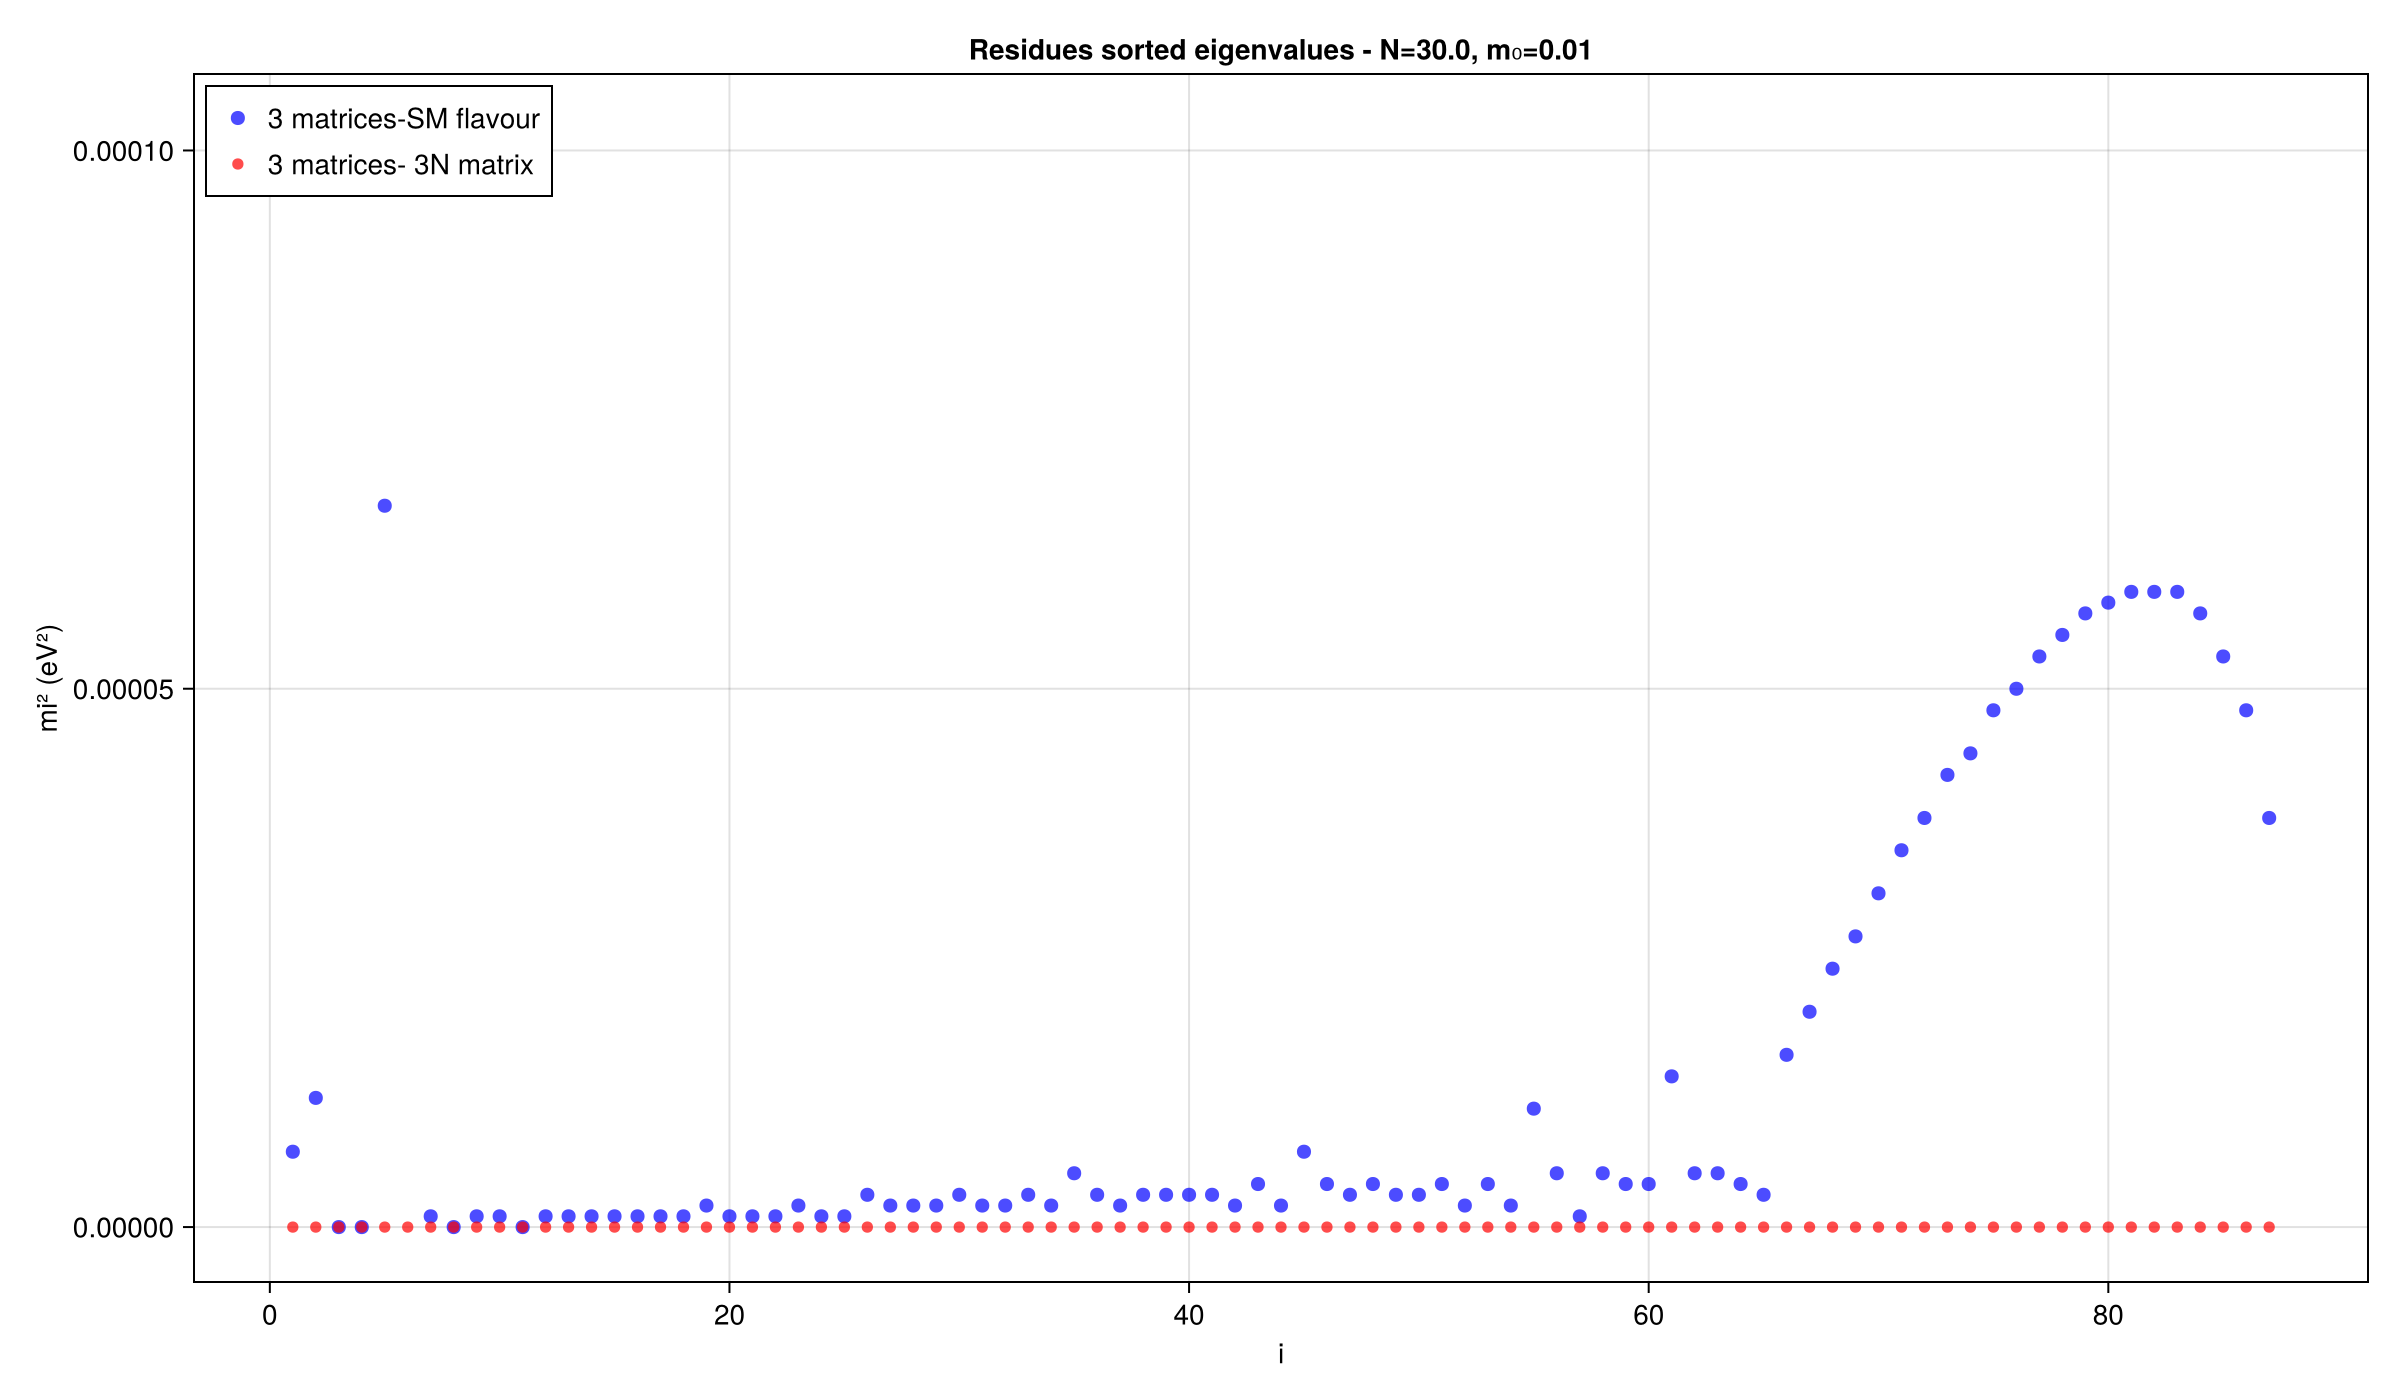

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using DelimitedFiles

# Read the three txt files
file1 = vec(readdlm("eigenvalues_noflavours.txt"))
file2 = vec(readdlm("eigenvalues_3N.txt"))
file3 = vec(readdlm("eigenvalues_3.txt"))

file1=sort(file1[1:end-3])
file2=sort(file2[1:end-3])
file3=sort(file3[1:end-3])

# Create indices for x-axis
indices1 = 1:length(file1)
indices2 = 1:length(file2)
indices3 = 1:length(file3)

N=p.N
m0=p.m₀

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="mi² (eV²)",
    title="Residues sorted eigenvalues - N=$N, m₀=$m0")

# Plot scatter points for each file with different colors

scatter!(ax, indices3, file3-file1, label="3 matrices-SM flavour", markersize=10, alpha=0.7, color=:blue)

#scatter!(ax, indices2, file2, label="3N matrix", markersize=8, alpha=0.9, color=:green)
scatter!(ax, indices1, file3-file2, label="3 matrices- 3N matrix", markersize=8, alpha=0.7, color=:red)
#ylims!(ax, -1e-4, 1e-4)
# Add legend
axislegend(ax, position=:lt)

# Save and display
#save("/home/sofialon/Newtrinos.jl/plot_final/general/residues_eigen_s_$N$m0.png", fig)
display(fig)


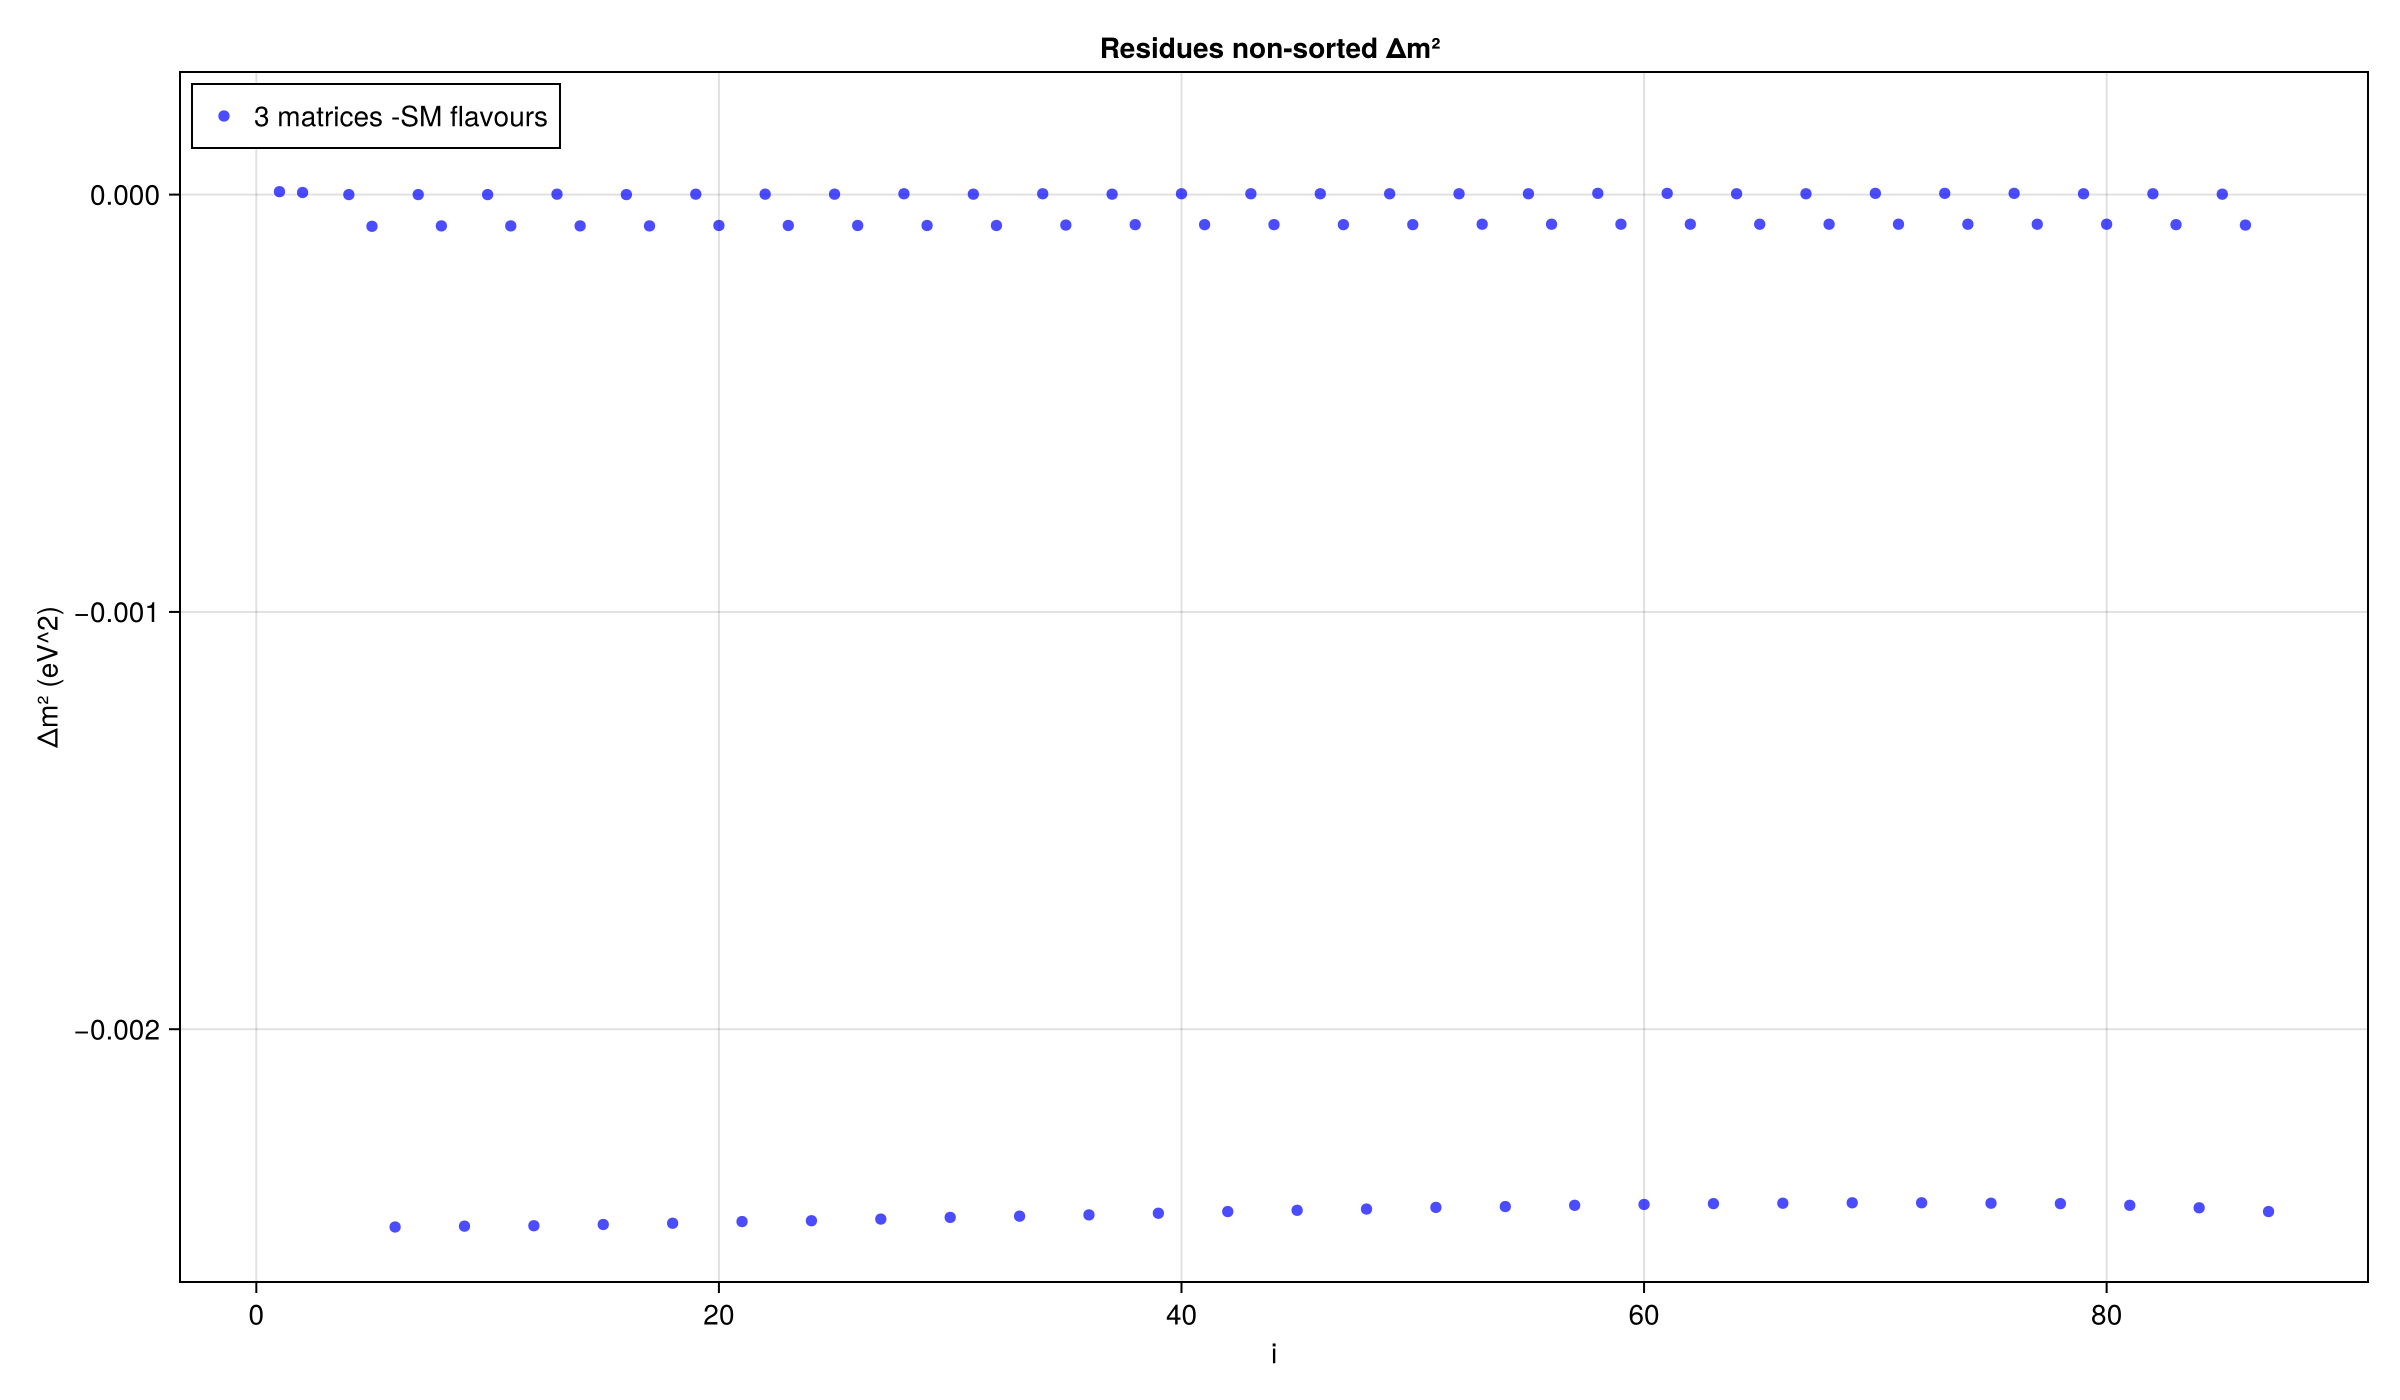

Plot saved as 'scatter_plot.png'


In [ ]:
using CairoMakie
using DelimitedFiles

# Read the three txt files
file1 = vec(readdlm("/home/sofialon/Newtrinos.jl/files_final/h_noflavours_N30_m0.01.txt"))
file2 = vec(readdlm("/home/sofialon/Newtrinos.jl/files_final/h_3N_N30_m0.01.txt"))
file3 = vec(readdlm("/home/sofialon/Newtrinos.jl/files_final/h_3_N30_m0.01.txt"))

file1=(file1[1:end-3])
file2=(file2[1:end-3])
file3=(file3[1:end-3])

# Create indices for x-axis
indices1 = 1:length(file1)
indices2 = 1:length(file2)
indices3 = 1:length(file3)

# Create the plot
fig = Figure(size=(1200, 700))
ax = Axis(fig[1, 1],
    xlabel="i",
    ylabel="Δm² (eV^2)",
    title="Residues non-sorted Δm² ")

# Plot scatter points for each file with different colors
#scatter!(ax, indices1, file3-file2, label="3 matrices - 3N matrix", markersize=8, alpha=0.7, color=:red)
scatter!(ax, indices2, file3-file1, label="3 matrices -SM flavours", markersize=8, alpha=0.7, color=:blue)
#scatter!(ax, indices3, file3, label="3 single matrices", markersize=8, alpha=0.7, color=:green)

# Add legend
axislegend(ax, position=:lt)


#save("/home/sofialon/Newtrinos.jl/plot_final/general/residues_h_ns_$N$m0.png", fig)
display(fig)

println("Plot saved as 'scatter_plot.png'")

In [8]:

# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

[ Info: Loading dayabay data


1000×1×3×3 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9717520812960653
 0.9683109007040173
 0.9648651711561107
 0.9614516539986672
 0.9581006425040238
 0.954836715800887
 0.9516794498955481
 0.948644075884838
 0.9457420805008407
 0.9429817476633987
 0.94036864212353
 0.9379060378509995
 0.9355952947774657
 ⋮
 0.9985934515549718
 0.9985961358673033
 0.9985988125173264
 0.9986014815341185
 0.9986041429466216
 0.9986067967836391
 0.9986094430738394
 0.9986120818457556
 0.9986147131277864
 0.998617336948196
 0.9986199533351169
 0.9986225623165482

[:, :, 2, 1] =
 0.005418083717743282
 0.006640561788994135
 0.007947011695303933
 0.009315085502218932
 0.01072495802678424
 0.012159222438124659
 0.013602747738296124
 0.015042513386734001
 0.016467432457965777
 0.017868171654777297
 0.019236974100273762
 0.02056748897953614
 0.02185461068877964
 ⋮
 0.000857674820230858
 0.0008560528141375867
 0.0008544353946927165
 0.0008528225446588595
 0.0008512142468793375
 0.000849610484277723
 0.0008480112398574

Plot oscillations and check the residues of the first three h

In [11]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(20), r= ftype(0),))
p_10 = merge(p, (N = ftype(20),r= ftype(0.25),))
p_20 = merge(p, (N = ftype(20),r= ftype(0.5),))
p_50 = merge(p, (N = ftype(20),r= ftype(1),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)


f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
FinalU_5, h_5 = f1(p_5)
FinalU_10, h_10 = f1(p_10)
FinalU_20, h_20 = f1(p_20)
FinalU_50, h_50 = f1(p_50)
h_SM=[0, p.Δm²₂₁, p.Δm²₃₁]


3-element Vector{Float64}:
 0.0
 7.53e-5
 0.0024752999999999997

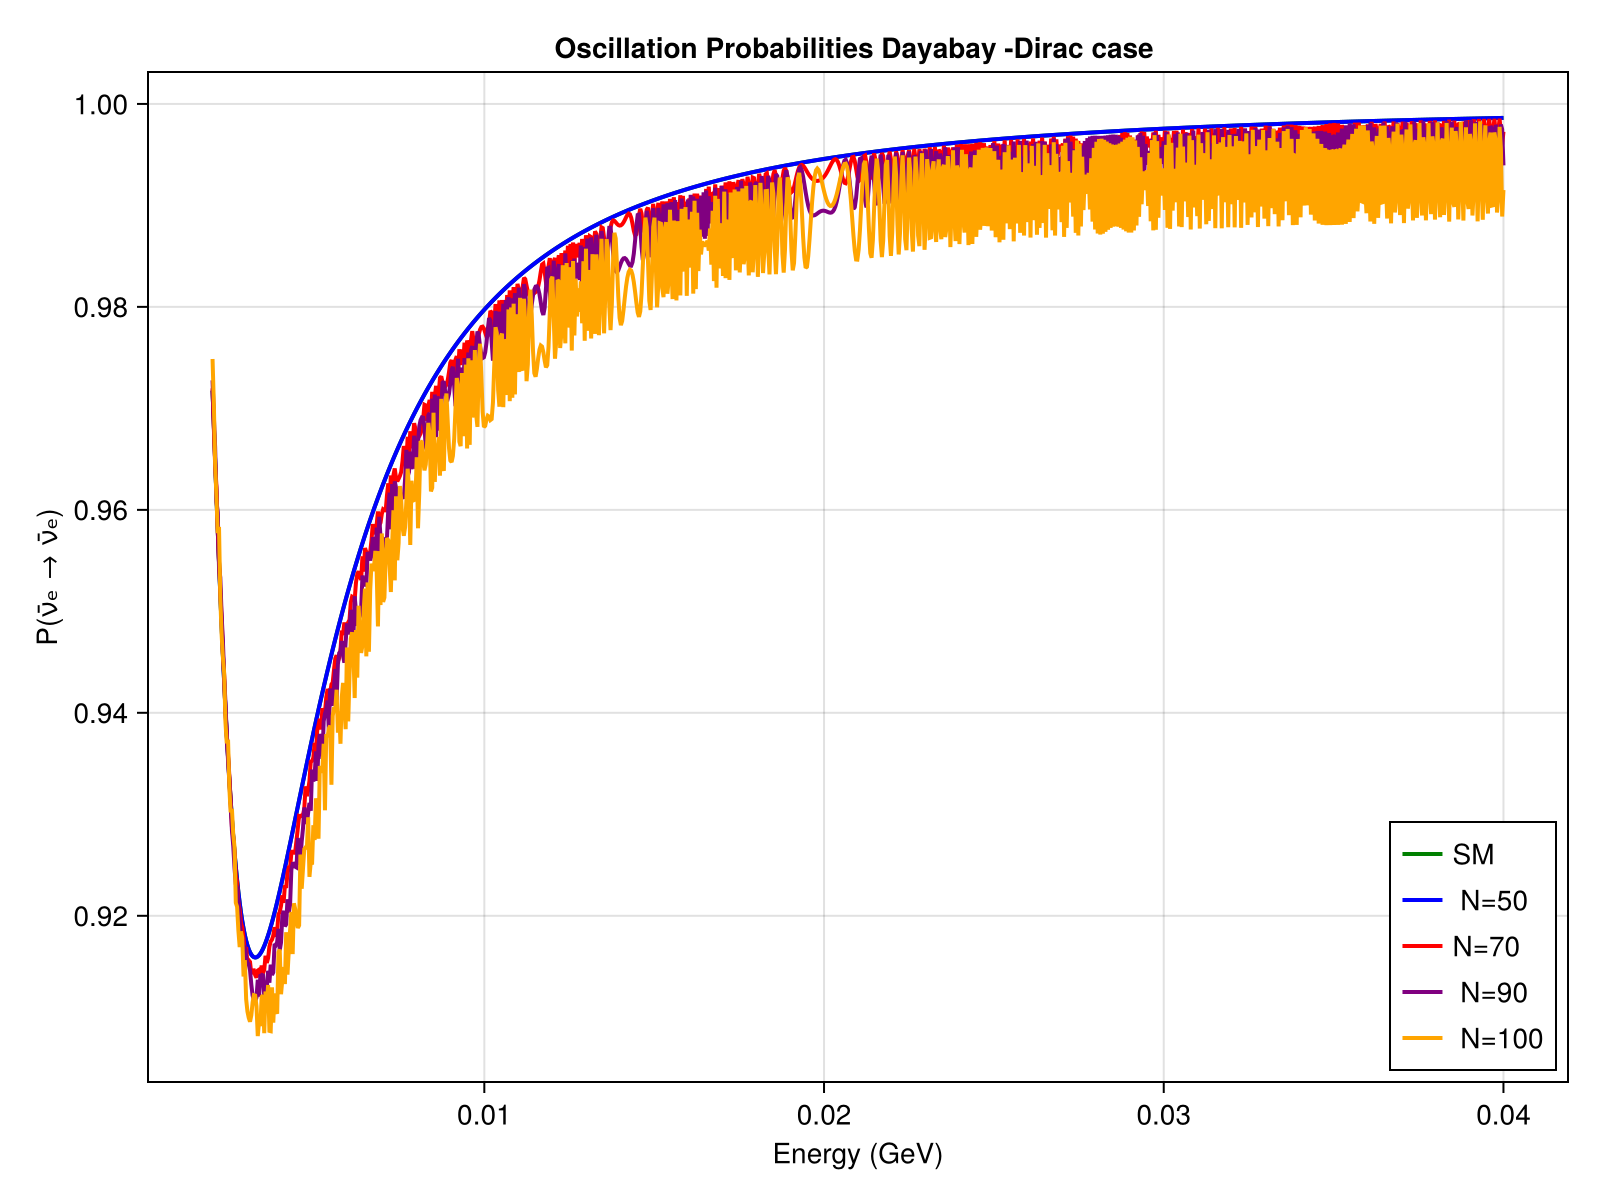

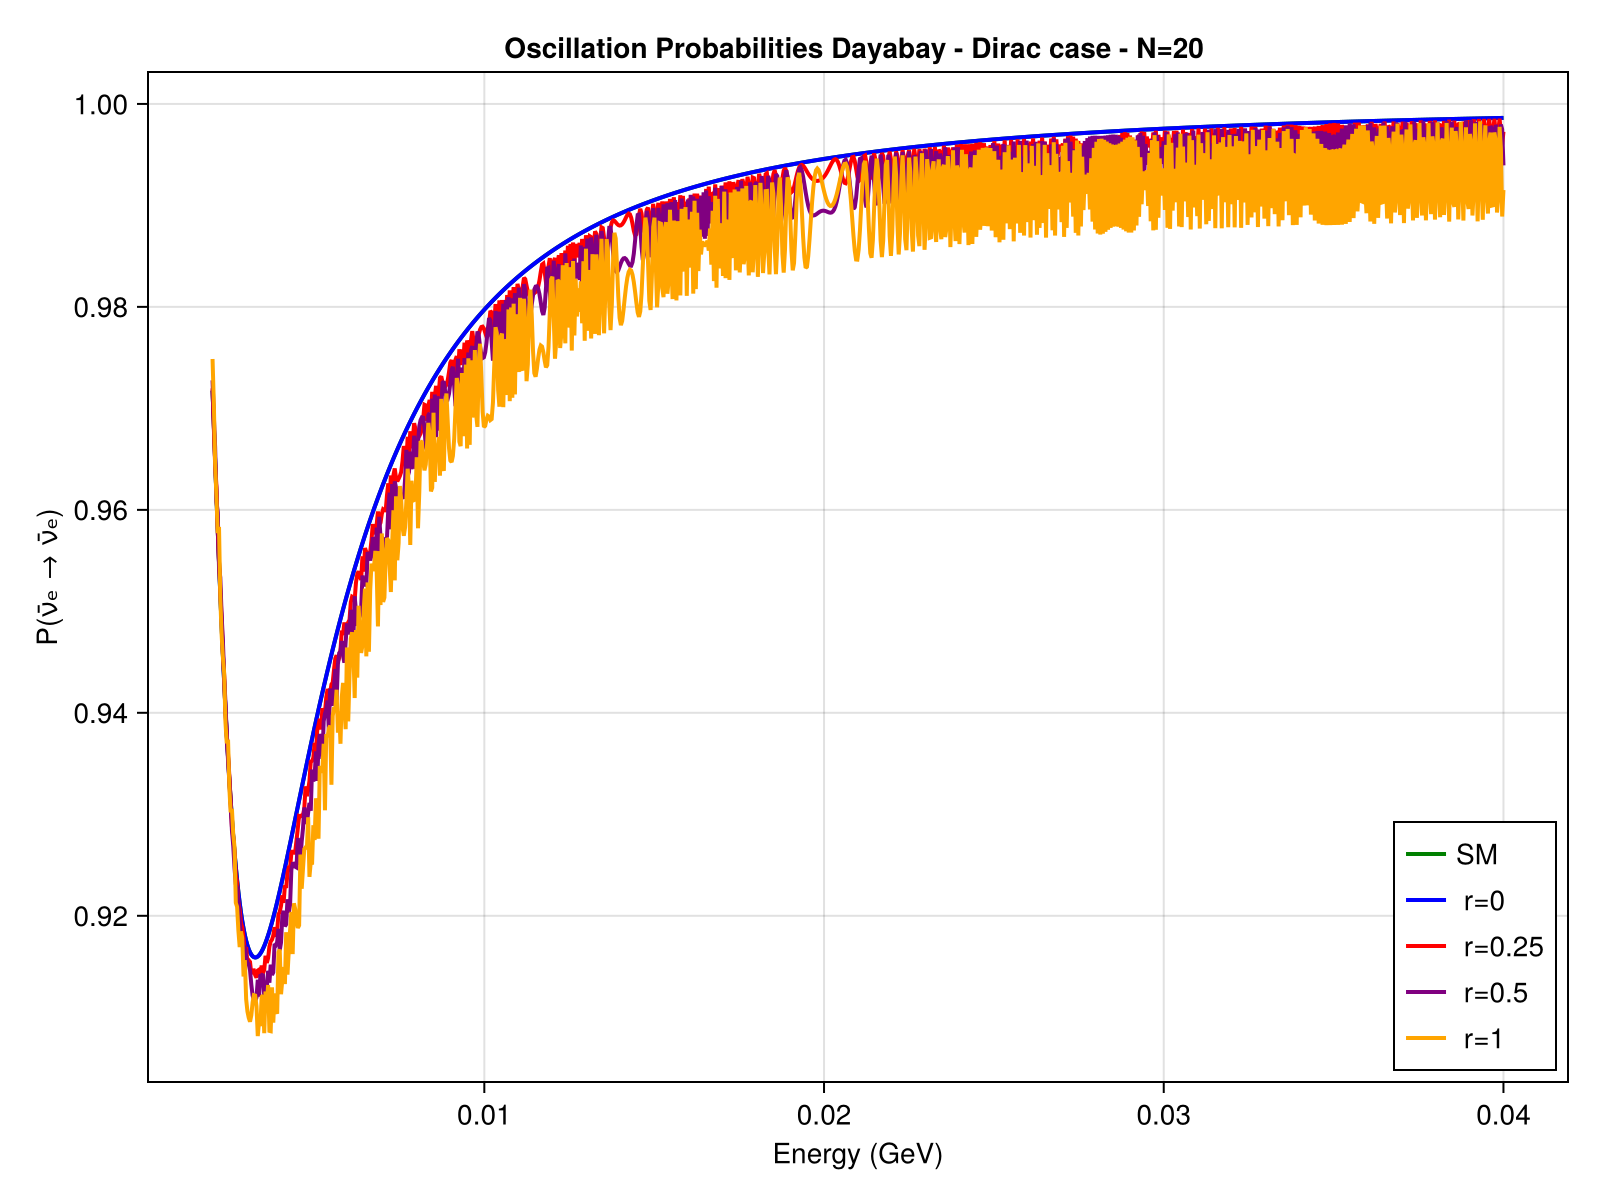

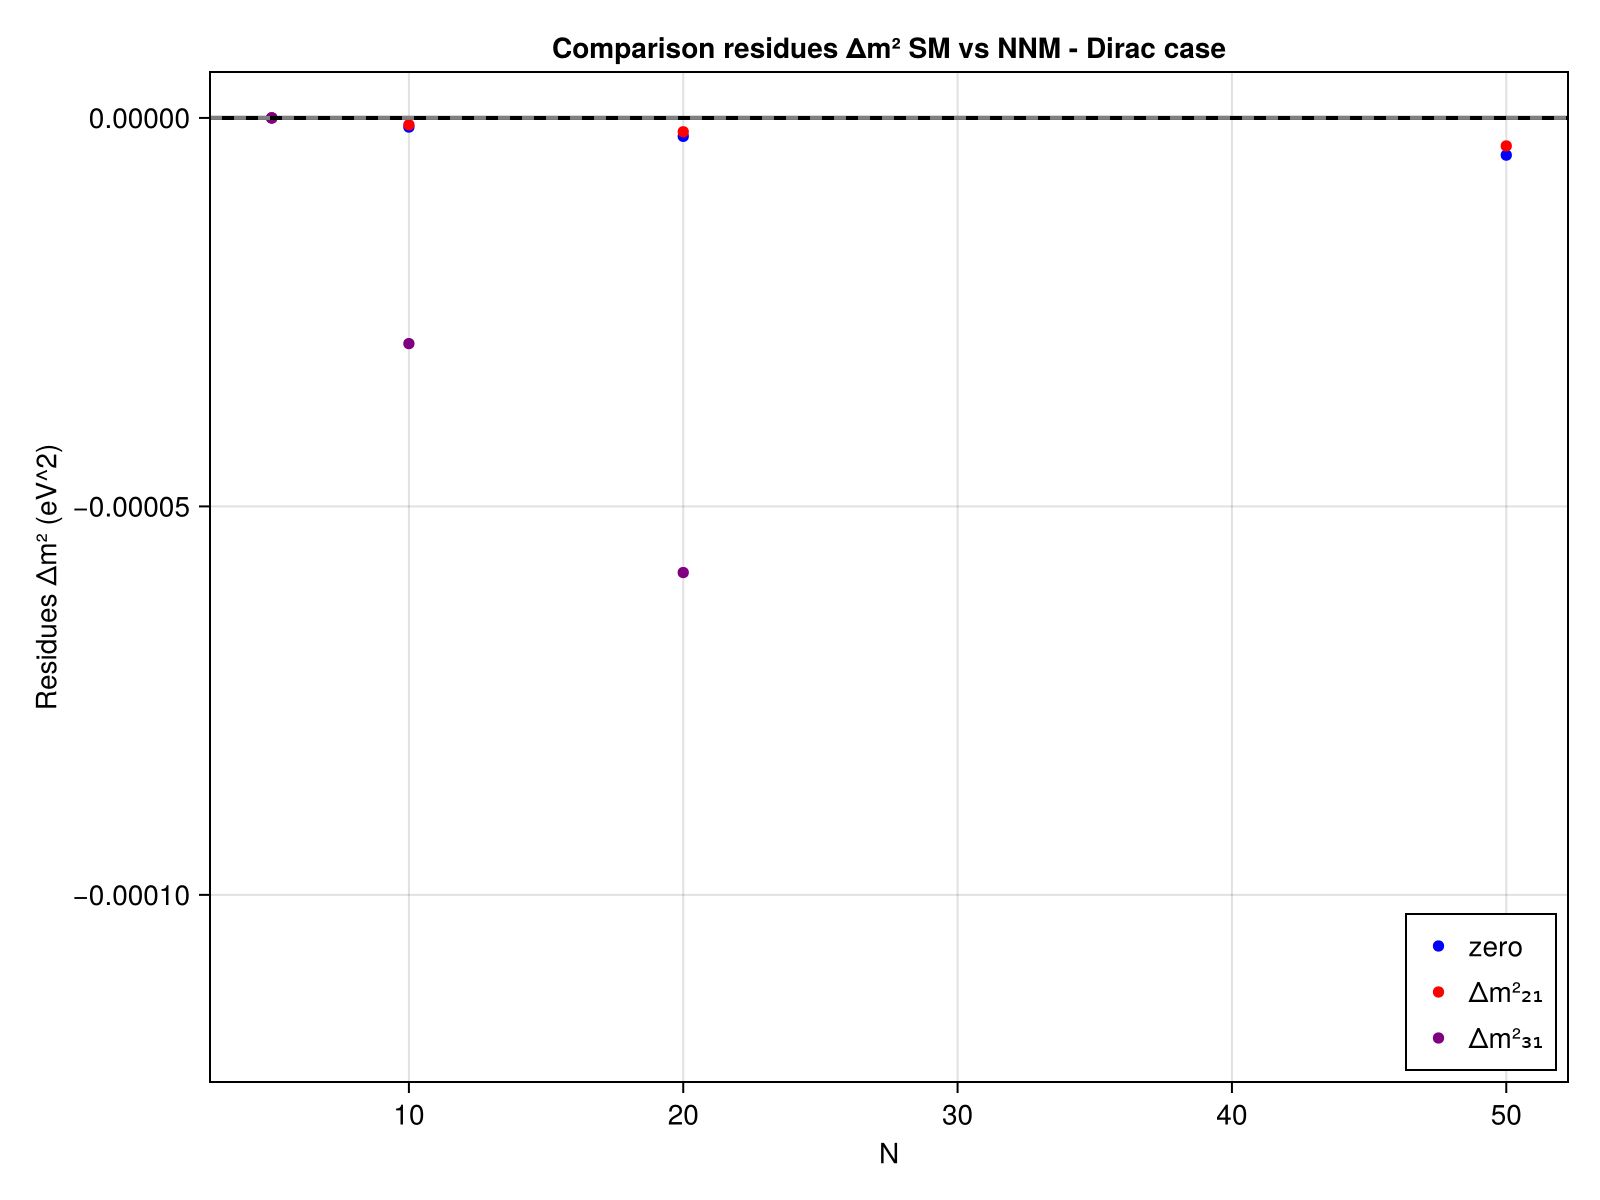

CairoMakie.Screen{IMAGE}


In [12]:

using CairoMakie


fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay -Dirac case "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=50", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=70", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=90", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=100", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/plot_final/oscillations/dayabay/osc_dayabay_N_NND_m0=0.01.png", fig)

fig
display(fig)


fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - N=20 "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label=" r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
save("/home/sofialon/Newtrinos.jl/plot_final/oscillations/dayabay/osc_dayabay_r_N20_NND_m0=0.01.png", fig)

fig
display(fig)


fig1= Figure(size=(800, 600))
ax1 = Axis(fig1[1,1], 
    xlabel = "N",
    ylabel = "Residues Δm² (eV^2)", 
    title = "Comparison residues Δm² SM vs NNM - Dirac case"
)

N_values = [5, 10, 20, 50]
diff_5 = h_SM .- h_5[1:3]
diff_10 = h_SM .- h_10[1:3]
diff_20 = h_SM .- h_20[1:3]
diff_50 = h_SM .- h_50[1:3]
differences = [diff_5, diff_10, diff_20, diff_50]

# Convert to proper matrix form
differences_matrix = hcat(differences...)  

limit=1e-9
# Plot each of the three difference types
scatter!(ax1, N_values, differences_matrix[1, :], label="zero", markersize=8, color=:blue)
scatter!(ax1, N_values, differences_matrix[2, :], label="Δm²₂₁", markersize=8, color=:red)
scatter!(ax1, N_values, differences_matrix[3, :], label="Δm²₃₁", markersize=8, color=:purple)
hlines!(ax1, limit, linewidth=2, color=:black)
hlines!(ax1, -limit, linewidth=2, color=:black)
hlines!(ax1, 0, linewidth=2, color=:gray, linestyle=:dash)


# Add legend
axislegend(ax1, position=:rb)
#save("/home/sofialon/Newtrinos.jl/plot_final/oscillations/dayabay/deltam2_dayabay_NNM_m0=0.01.png", fig1)

fig1
display(fig1)



Numerical instabilities

Eigenvalues comparison with different precision

In [8]:
using LinearAlgebra
using Printf

function convert_namedtuple_type(nt::NamedTuple, T::Type)
    """
    Convert all numeric values in a NamedTuple to type T.
    """
    dict = Dict()
    for (k, v) in pairs(nt)
        if v isa Number
            dict[k] = T(v)
        else
            dict[k] = v
        end
    end
    return NamedTuple(dict)
end

function test_precision_all_params(params_base::NamedTuple, param_name::Symbol, param_values::Vector)
    """
    Test get_matrices across different precisions for varying parameter.
    Compares Float64, Float32, and BigFloat results.
    """
    
    results = Dict(
        :Float64 => [],
        :Float32 => [],
        :BigFloat => []
    )
    
    println("\n" * "="^100)
    println("PRECISION COMPARISON TEST")
    println("Parameter: $param_name")
    println("="^100)
   
    for param_value in param_values
      
        println("\n" * "-"^100)
        println("Parameter value: $param_value")
        println("-"^100)
     
        # Update parameter
        params = merge(params_base, (param_name => param_value,))
        
        # Float64 (standard)
        println("\n→ Float64 (standard precision, ~15 digits)")
        try            
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            _,evals_f64 = f1(params)
            #println("Computed eigenvalues (unsorted): $(real(evals_f64))")
            #evals_f64_sorted = sort(real(evals_f64))
            push!(results[:Float64], real(evals_f64))
            println("✓ Computed successfully")
            println("  First 8 eigenvalues:")
            for (i, e) in enumerate(real(evals_f64)[1:min(8, length(real(evals_f64)))])
                @printf("    λ_%d = %.15e\n", i, e)
            end
        catch e
            push!(results[:Float64], nothing)
            println("✗ Error: $(string(typeof(e)))")
            println("  $e")
        end
        
        # Float32 (lower precision)
        println("\n→ Float32 (lower precision, ~7 digits)")
        try
            params_f32 = convert_namedtuple_type(params, Float32)
            f1_f32 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            _,evals_f32= f1_f32(params_f32)
            #evals_f32_sorted = sort(real(evals_f32))
            push!(results[:Float32], real(evals_f32))
            println("✓ Computed successfully")
            println("  First 8 eigenvalues:")
            for (i, e) in enumerate(real(evals_f32)[1:min(8, length(real(evals_f32)))])
                @printf("    λ_%d = %.7e\n", i, e)
            end
        catch e
            push!(results[:Float32], nothing)
            println("✗ Error: $(string(typeof(e)))")
            println("  $e")
        end
        
        # BigFloat (high precision)
        println("\n→ BigFloat (arbitrary precision, 256 bits ~ 77 decimal digits)")
        try
            setprecision(BigFloat, 256)
            params_bf = convert_namedtuple_type(params, BigFloat)
            f1_bf = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            _,evals_bf= f1_bf(params_bf)
            #evals_bf_sorted = sort(real(evals_bf))
            push!(results[:BigFloat], real(evals_bf))
            println("✓ Computed successfully")
            println("  First 8 eigenvalues:")
            for (i, e) in enumerate(real(evals_bf)[1:min(8, length(real(evals_bf)))])
                @printf("    λ_%d = %.30e\n", i, e)
            end
        catch e
            push!(results[:BigFloat], nothing)
            println("✗ Error: $(string(typeof(e)))")
            println("  $e")
        end
        
        # Compare results
        println("\n" * "="^100)
        println("COMPARISON (Float64 vs BigFloat)")
        println("="^100)
        
        if results[:Float64][end] !== nothing && results[:BigFloat][end] !== nothing
            min_len = min(length(results[:Float64][end]), length(results[:BigFloat][end]))
            diff = results[:Float64][end][1:min_len] .- results[:BigFloat][end][1:min_len]
            max_abs_diff = maximum(abs.(diff))
            
            println("\nAbsolute differences:")
            for i in 1:min(5, min_len)
                @printf("  λ_%d: %.3e (Float64: %.15e, BigFloat: %.30e)\n", 
                    i, abs(diff[i]), results[:Float64][end][i], results[:BigFloat][end][i])
            end
            
            println("\nMax absolute difference: $max_abs_diff")
            
            # Relative error (only if BigFloat value is not too small)
            println("\nRelative differences:")
            for i in 1:min(5, min_len)
                if abs(results[:BigFloat][end][i]) > 1e-30
                    rel_diff = abs(diff[i]) / abs(results[:BigFloat][end][i])
                    @printf("  λ_%d: %.3e (relative)\n", i, rel_diff)
                else
                    @printf("  λ_%d: (BigFloat value too small)\n", i)
                end
            end
            
            if max_abs_diff > 1e-10
                println("\n  ⚠️  WARNING: Significant disagreement - likely NUMERICAL INSTABILITY!")
            else
                println("\n  ✓ Consistent across precisions - likely PHYSICAL BEHAVIOR")
            end
        elseif results[:Float64][end] !== nothing && results[:Float32][end] !== nothing
            # Fallback comparison if BigFloat fails
            min_len = min(length(results[:Float64][end]), length(results[:Float32][end]))
            diff = results[:Float64][end][1:min_len] .- results[:Float32][end][1:min_len]
            max_abs_diff = maximum(abs.(diff))
            
            println("\n(BigFloat test failed - comparing Float64 vs Float32 instead)")
            println("Max absolute difference: $max_abs_diff")
            if max_abs_diff > 1e-5
                println("  ⚠️  Even Float32/Float64 disagree - likely NUMERICAL INSTABILITY!")
            else
                println("  ✓ Float32/Float64 agree - probably acceptable")
            end
        else
            println("\n✗ Cannot compare - at least one precision test failed")
        end
    end
    
    return results
end

function analyze_single_parameter(params::NamedTuple, osc_cfg)
    """
    Detailed analysis at a single parameter point.
    """
 
    println("\n" * "="^100)
    println("DETAILED SINGLE PARAMETER ANALYSIS")
    println("="^100)
    
    # Float64
    println("\n→ Float64:")
    f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    _, evals_f64 = f1(params)
    evals_f64_sorted = sort(real(evals_f64))
    println("First 10 eigenvalues:")
    for (i, e) in enumerate(evals_f64_sorted[1:min(10, length(evals_f64_sorted))])
        @printf("  λ_%d = %.15e\n", i, e)
    end
    
    # BigFloat
    println("\n→ BigFloat (256 bits):")
    setprecision(BigFloat, 256)
    params_bf = convert_namedtuple_type(params, BigFloat)
    f1_bf = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    _, evals_bf = f1_bf(params_bf)
    evals_bf_sorted = sort(real(evals_bf))
    println("First 10 eigenvalues:")
    for (i, e) in enumerate(evals_bf_sorted[1:min(10, length(evals_bf_sorted))])
        @printf("  λ_%d = %.30e\n", i, e)
    end
    
    return evals_f64_sorted, evals_bf_sorted
end

# Define your base parameters
params_base = p

# TEST 1: Sweep over parameter that shows anomaly
println("\n🔬 TEST 1: Parameter sweep for anomalous behavior\n")
param_values = [0.001, 0.01, 0.1, 0.3]  # Adjust to your problematic range
results = test_precision_all_params(params_base, :m₀, param_values)



🔬 TEST 1: Parameter sweep for anomalous behavior


PRECISION COMPARISON TEST
Parameter: m₀

----------------------------------------------------------------------------------------------------
Parameter value: 0.001
----------------------------------------------------------------------------------------------------

→ Float64 (standard precision, ~15 digits)
✓ Computed successfully
  First 8 eigenvalues:
    λ_1 = 1.977832729038518e-08
    λ_2 = 7.678929647706952e-05
    λ_3 = 2.524254931647071e-03
    λ_4 = 8.171641784501433e-06
    λ_5 = 6.234961716739525e-04
    λ_6 = 2.023541681094046e-02
    λ_7 = 2.446340295614147e-05
    λ_8 = 1.866557392740718e-03

→ Float32 (lower precision, ~7 digits)
✓ Computed successfully
  First 8 eigenvalues:
    λ_1 = 7.2062448e-08
    λ_2 = 7.8428136e-05
    λ_3 = 2.4963969e-03
    λ_4 = 7.9321781e-06
    λ_5 = 6.2965963e-04
    λ_6 = 2.0193163e-02
    λ_7 = 2.3981391e-05
    λ_8 = 1.8731512e-03

→ BigFloat (arbitrary precision, 256 bits ~ 77 decimal 

Dict{Symbol, Vector{Any}} with 3 entries:
  :BigFloat => [BigFloat[1.97783e-08, 7.67893e-05, 0.00252425, 8.17164e-06, 0.0…
  :Float32  => [Float32[7.20624f-8, 7.84281f-5, 0.0024964, 7.93218f-6, 0.000629…
  :Float64  => [[1.97783e-8, 7.67893e-5, 0.00252425, 8.17164e-6, 0.000623496, 0…

Eigenvector comparison with different precision

In [9]:

function compare_eigenvector_matrices_quiet(params::NamedTuple, osc_cfg)
    """
    Compare eigenvector matrices from Float64 vs BigFloat.
    Returns only the overlaps (not verbose).
    """
    
    # Float64
    evecs_f64, _ = Newtrinos.osc.get_matrices(osc_cfg.flavour)(params)
    
    # BigFloat
    setprecision(BigFloat, 256)
    params_bf = convert_namedtuple_type(params, BigFloat)
    evecs_bf, _ = Newtrinos.osc.get_matrices(osc_cfg.flavour)(params_bf)
    
    # Compare
    n_cols = min(size(evecs_f64, 2), size(evecs_bf, 2))
    overlaps = Float64[]
    
    for i in 1:n_cols
        overlap = abs(vec(evecs_f64[:, i])' * vec(evecs_bf[:, i]))
        push!(overlaps, overlap)
    end
    
    return overlaps
end

function test_multiple_m0_values(params_base::NamedTuple, osc_cfg, m0_values::Vector)
    """
    Test eigenvector agreement for multiple m₀ values.
    
    Shows which eigenvectors agree/disagree across the parameter sweep.
    """
    
    println("\n" * "="^100)
    println("EIGENVECTOR COMPARISON SWEEP OVER m₀ VALUES")
    println("="^100)
    
    all_results = Dict()
    
    for m0 in m0_values
        println("\n" * "-"^100)
        println("m₀ = $m0")
        println("-"^100)
        
        # Update parameter
        params = merge(params_base, (:m₀ => m0,))
        
        # Compare eigenvectors
        overlaps = compare_eigenvector_matrices_quiet(params, osc_cfg)
        all_results[m0] = overlaps
        
        # Statistics
        n_excellent = count(x -> x > 0.99, overlaps)
        n_very_good = count(x -> 0.95 < x ≤ 0.99, overlaps)
        n_good = count(x -> 0.90 < x ≤ 0.95, overlaps)
        n_moderate = count(x -> 0.70 < x ≤ 0.90, overlaps)
        n_poor = count(x -> x ≤ 0.70, overlaps)
        
        n_total = length(overlaps)
        
        println("Agreement distribution:")
        @printf("  Excellent (>0.99):     %3d (%.1f%%)\n", n_excellent, 100*n_excellent/n_total)
        @printf("  Very good (0.95-0.99): %3d (%.1f%%)\n", n_very_good, 100*n_very_good/n_total)
        @printf("  Good (0.90-0.95):      %3d (%.1f%%)\n", n_good, 100*n_good/n_total)
        @printf("  Moderate (0.70-0.90):  %3d (%.1f%%)\n", n_moderate, 100*n_moderate/n_total)
        @printf("  Poor (<0.70):          %3d (%.1f%%)\n", n_poor, 100*n_poor/n_total)
        
        # Detect tier structure
        physical_threshold = 0.95
        physical_count = count(x -> x > physical_threshold, overlaps)
        spurious_count = count(x -> x < 0.70, overlaps)
        
        if physical_count > 0 && spurious_count > 0
            println("\n  → Tier structure: ~$(physical_count) physical, ~$(spurious_count) spurious")
        elseif physical_count == n_total
            println("\n  → All eigenvectors reliable (no spurious)")
        else
            println("\n  → Mixed agreement pattern")
        end
    end
    
    # ==================== SUMMARY ACROSS ALL m₀ ====================
    
    println("\n" * "="^100)
    println("SUMMARY ACROSS ALL m₀ VALUES")
    println("="^100)
    
    println("\nWhich eigenvectors are consistent across all m₀?")
    println("(High overlap at every m₀ = physical, low overlap somewhere = questionable)")
    
    # For each eigenvector, check if it has high overlap for ALL m₀ values
    if length(all_results) > 0
        n_eigs = length(first(values(all_results)))
        threshold = 0.95
        
        consistent_physical = 0
        sometimes_questionable = 0
        often_spurious = 0
        
        for eig_idx in 1:n_eigs
            overlaps_this_eig = [all_results[m0][eig_idx] for m0 in m0_values]
            
            min_overlap = minimum(overlaps_this_eig)
            max_overlap = maximum(overlaps_this_eig)
            
            if min_overlap > threshold
                consistent_physical += 1
            elseif min_overlap > 0.70
                sometimes_questionable += 1
            else
                often_spurious += 1
            end
        end
        
        println("\n  Consistently physical (overlap > $threshold for all m₀):  $consistent_physical")
        println("  Sometimes questionable (overlap > 0.70 for all m₀):    $sometimes_questionable")
        println("  Often spurious (overlap < 0.70 for some m₀):          $often_spurious")
        
        if consistent_physical > 0
            println("\n  → First ~$(consistent_physical) eigenvectors are PHYSICAL across all tested m₀")
            println("  → Last ~$(often_spurious) eigenvectors are SPURIOUS")
        end
    end
    
    return all_results
end

# USAGE EXAMPLE:

m0_values = [0.001, 0.01, 0.1]
results = test_multiple_m0_values(p, osc_cfg, m0_values)



EIGENVECTOR COMPARISON SWEEP OVER m₀ VALUES

----------------------------------------------------------------------------------------------------
m₀ = 0.001
----------------------------------------------------------------------------------------------------
Agreement distribution:
  Excellent (>0.99):     300 (100.0%)
  Very good (0.95-0.99):   0 (0.0%)
  Good (0.90-0.95):        0 (0.0%)
  Moderate (0.70-0.90):    0 (0.0%)
  Poor (<0.70):            0 (0.0%)

  → All eigenvectors reliable (no spurious)

----------------------------------------------------------------------------------------------------
m₀ = 0.01
----------------------------------------------------------------------------------------------------
Agreement distribution:
  Excellent (>0.99):     300 (100.0%)
  Very good (0.95-0.99):   0 (0.0%)
  Good (0.90-0.95):        0 (0.0%)
  Moderate (0.70-0.90):    0 (0.0%)
  Poor (<0.70):            0 (0.0%)

  → All eigenvectors reliable (no spurious)

-------------------------

Dict{Any, Any} with 3 entries:
  0.01  => [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0,…
  0.1   => [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0,…
  0.001 => [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0,…

Highest and lowest eigenvalues - eigenvalues with m0

In [23]:
using CairoMakie

function sweep_m0_and_plot_eigenvalues(params_base::NamedTuple, osc_cfg, m0_values)
    """
    Sweep over m0 values and plot:
    - 3 highest eigenvalues
    - 3 lowest eigenvalues
    
    All on one plot using CairoMakie.
    """
    
    println("\n" * "="^100)
    println("EIGENVALUE SWEEP OVER m₀ VALUES ")
    println("="^100)
    
    # Storage for results
    eigenvalues_all = Dict()
    
    for m0 in m0_values
        println("m₀ = $m0")
        
        # Update parameter
        params = merge(params_base, (:m₀ => m0,))
        
        # Get eigenvalues
        U, evals = Newtrinos.osc.get_matrices(osc_cfg.flavour)(params)
        
        eigenvalues_all[m0] = (abs.(evals))
        
        println("  Min eigenvalue: $(evals[1])")
        println("  Max eigenvalue: $(evals[end])")
    end
    
    # ==================== PREPARE DATA FOR PLOTTING ====================
    
    println("\n" * "="^100)
    println("PREPARING PLOTS")
    println("="^100)
    
    # Sort m0 values for plotting
    m0_sorted = (m0_values)
    
    # Extract 3 lowest and 3 highest for each m0
    lowest_1 = Float64[]
    lowest_2 = Float64[]
    lowest_3 = Float64[]
    
    highest_1 = Float64[]  # highest
    highest_2 = Float64[]  # second highest
    highest_3 = Float64[]  # third highest
    
    for m0 in m0_sorted
        evals = eigenvalues_all[m0]
        
        # 3 lowest
        push!(lowest_1, evals[1])
        push!(lowest_2, evals[2])
        push!(lowest_3, evals[3])
        
        # 3 highest
        push!(highest_3, evals[4])  # third highest
        push!(highest_2, evals[5])  # second highest
        push!(highest_1, evals[6])    # highest
    end
    
    # ==================== CREATE PLOT ====================
    
    println("Creating plot ...")
    
    fig = Figure(size=(1000, 600))
    ax = Axis(fig[1, 1],
        title="Eigenvalues vs m₀",
        xlabel="m₀ (eV)",
        ylabel="Eigenvalue (eV^2)",
        yscale=log10,  # Optional: logarithmic y-axis
    )
    
    # Plot 3 lowest eigenvalues (solid lines)
    lines!(ax, m0_sorted, lowest_1, label="λ₁ ", linewidth=2, color=:blue)
    lines!(ax, m0_sorted, lowest_2, label="λ₂", linewidth=2, color=:green)
    lines!(ax, m0_sorted, lowest_3, label="λ₃", linewidth=2, color=:orange)
    
    # Plot 3 highest eigenvalues (dashed lines)
    lines!(ax, m0_sorted, highest_3, label="λ₄", 
           linewidth=2, color=:red)
    lines!(ax, m0_sorted, highest_2, label="λ₅", 
           linewidth=2, color=:purple)
    lines!(ax, m0_sorted, highest_1, label="λ₆", 
           linewidth=2, color=:brown)

    # Add scatter points
    scatter!(ax, m0_sorted, lowest_1, color=:blue, markersize=6)
    scatter!(ax, m0_sorted, lowest_2, color=:green, markersize=6)
    scatter!(ax, m0_sorted, lowest_3, color=:orange, markersize=6)
    scatter!(ax, m0_sorted, highest_3, color=:red, markersize=6)
    scatter!(ax, m0_sorted, highest_2, color=:purple, markersize=6)
    scatter!(ax, m0_sorted, highest_1, color=:brown, markersize=6)
    
    # Add legend
    axislegend(ax, position=:rt)
    
    # Save plot
    save("/home/sofialon/Newtrinos.jl/plot_final/eigen_3N/NND/eigenvalues_vs_m0_3_high.png", fig)
    println("✓ Plot saved as 'eigenvalues_vs_m0_high.png'")

    return fig, eigenvalues_all
end

# USAGE:

m0_values = LinRange(0.03, 0.3, 100)  # 50 points
fig, results = sweep_m0_and_plot_eigenvalues(p, osc_cfg, m0_values)


EIGENVALUE SWEEP OVER m₀ VALUES 
m₀ = 0.03
  Min eigenvalue: 0.0009088566691757351
  Max eigenvalue: 0.6702161524301172
m₀ = 0.03272727272727273
  Min eigenvalue: 0.0010816145484405446
  Max eigenvalue: 0.7041855220576028
m₀ = 0.035454545454545454
  Min eigenvalue: 0.0012693948519892498
  Max eigenvalue: 0.7411087498887772
m₀ = 0.03818181818181818
  Min eigenvalue: 0.0014721975798218517
  Max eigenvalue: 0.7809858359174374
m₀ = 0.04090909090909091
  Min eigenvalue: 0.0016900227319383504
  Max eigenvalue: 0.8238167801569146
m₀ = 0.04363636363636363
  Min eigenvalue: 0.001922870308338745
  Max eigenvalue: 0.8696015826125499
m₀ = 0.046363636363636364
  Min eigenvalue: 0.0021707403090230368
  Max eigenvalue: 0.9183402432765361
m₀ = 0.04909090909090909
  Min eigenvalue: 0.0024336327339912244
  Max eigenvalue: 0.9700327621608971
m₀ = 0.05181818181818182
  Min eigenvalue: 0.0027115475832433095
  Max eigenvalue: 1.0246791392684584
m₀ = 0.05454545454545454
  Min eigenvalue: 0.00300448485677929

(Scene (1000px, 600px):
  0 Plots
  2 Child Scenes:
    ├ Scene (1000px, 600px)
    └ Scene (1000px, 600px), Dict{Any, Any}(0.14727272727272728 => [0.021902694605921025, 0.021978735604210115, 0.024402353372474976, 0.06568530198113359, 0.06591334591000085, 0.07318167829664311, 0.10944675260808892, 0.10982672600573794, 0.12193743195385054, 0.15319214820180097  …  4.648950971929499, 4.2170472450171, 4.231687841894397, 4.698320412776233, 4.2616037766286485, 4.276399063627024, 4.747961986775185, 4.306725285334368, 4.321677223350019, 4.798233015989838], 0.16363636363636364 => [0.027040363711013607, 0.027116404726214422, 0.029540022472925483, 0.0810929654088069, 0.08132100934914749, 0.08858934172846643, 0.1351194476643073, 0.13549942107329666, 0.14761012700809106, 0.18912610889111228  …  5.6277406563484345, 5.206231166687778, 5.220871763625166, 5.687504334512925, 5.261239230405739, 5.276034516770732, 5.74759744052517, 5.3169447967090955, 5.331896734620719, 5.808452527369859], 0.16909090909090

In [25]:


function sweep_m0_and_plot_first_15_eigenvalues(params_base::NamedTuple, osc_cfg, m0_values)
    """
    Sweep over m0 values and plot:
    - First 15 eigenvalues
    
    All on one plot using CairoMakie.
    """
    
    println("\n" * "="^100)
    println("EIGENVALUE SWEEP OVER m₀ VALUES (First 15 eigenvalues)")
    println("="^100)
    
    # Storage for results
    eigenvalues_all = Dict()
    
    for m0 in m0_values
        println("m₀ = $m0")
        
        # Update parameter
        params = merge(params_base, (:m₀ => m0,))
        
        # Get eigenvalues
        U, evals = Newtrinos.osc.get_matrices(osc_cfg.flavour)(params)

        eigenvalues_all[m0] = (evals)

        println("  Min eigenvalue: $(evals[1])")
        println("  Max eigenvalue: $(evals[end])")
    end
    
    # ==================== PREPARE DATA FOR PLOTTING ====================
    
    println("\n" * "="^100)
    println("PREPARING PLOTS")
    println("="^100)
    
    # Sort m0 values for plotting
    m0_sorted = (m0_values)
    
    # Extract first 15 eigenvalues for each m0
    evals_by_index = [Float64[] for _ in 1:15]
    
    for m0 in m0_sorted
        evals = eigenvalues_all[m0]
        
        # First 15 eigenvalues
        for i in 1:15
            push!(evals_by_index[i], evals[i])
        end
    end
    
    # ==================== CREATE PLOT ====================
    
    println("Creating plot ...")
    
    fig = Figure(size=(1000, 600))
    ax = Axis(fig[1, 1],
        title="First 15 Eigenvalues vs m₀",
        xlabel="m₀ (eV)",
        ylabel="Eigenvalue (eV^2)",
        yscale=log10,  # Optional: logarithmic y-axis
    )
    
    # Define colors for each eigenvalue
    colors = [:blue, :green, :orange, :red, :purple, :brown, 
              :pink, :cyan, :magenta, :yellow, :gray, :black,
              :olive, :navy, :teal]
    
    # Plot all 15 eigenvalues
    for i in 1:15
        lines!(ax, m0_sorted, evals_by_index[i], label="λ_$i", 
               linewidth=2, color=colors[i])
        scatter!(ax, m0_sorted, evals_by_index[i], color=colors[i], markersize=5)
    end
    
    # Add legend
   # axislegend(ax, position=:rt)
    
    # Save plot
    save("/home/sofialon/Newtrinos.jl/plot_final/eigen_3N/NND/eigenvalues_vs_m0_first15_3_high.png", fig)
    println("✓ Plot saved as 'eigenvalues_vs_m0_first15_3.png'")
    return fig, eigenvalues_all
end

# USAGE:
 m0_values = LinRange(0.03, 0.3, 100)  # 100 points
 fig, results = sweep_m0_and_plot_first_15_eigenvalues(p, osc_cfg, m0_values)


EIGENVALUE SWEEP OVER m₀ VALUES (First 15 eigenvalues)
m₀ = 0.03
  Min eigenvalue: 0.0009088566691757351
  Max eigenvalue: 0.6702161524301172
m₀ = 0.03272727272727273
  Min eigenvalue: 0.0010816145484405446
  Max eigenvalue: 0.7041855220576028
m₀ = 0.035454545454545454
  Min eigenvalue: 0.0012693948519892498
  Max eigenvalue: 0.7411087498887772
m₀ = 0.03818181818181818
  Min eigenvalue: 0.0014721975798218517
  Max eigenvalue: 0.7809858359174374
m₀ = 0.04090909090909091
  Min eigenvalue: 0.0016900227319383504
  Max eigenvalue: 0.8238167801569146
m₀ = 0.04363636363636363
  Min eigenvalue: 0.001922870308338745
  Max eigenvalue: 0.8696015826125499
m₀ = 0.046363636363636364
  Min eigenvalue: 0.0021707403090230368
  Max eigenvalue: 0.9183402432765361
m₀ = 0.04909090909090909
  Min eigenvalue: 0.0024336327339912244
  Max eigenvalue: 0.9700327621608971
m₀ = 0.05181818181818182
  Min eigenvalue: 0.0027115475832433095
  Max eigenvalue: 1.0246791392684584
m₀ = 0.05454545454545454
  Min eigenvalu

(Scene (1000px, 600px):
  0 Plots
  1 Child Scene:
    └ Scene (1000px, 600px), Dict{Any, Any}(0.14727272727272728 => [0.021902694605921025, 0.021978735604210115, 0.024402353372474976, 0.06568530198113359, 0.06591334591000085, 0.07318167829664311, 0.10944675260808892, 0.10982672600573794, 0.12193743195385054, 0.15319214820180097  …  4.648950971929499, 4.2170472450171, 4.231687841894397, 4.698320412776233, 4.2616037766286485, 4.276399063627024, 4.747961986775185, 4.306725285334368, 4.321677223350019, 4.798233015989838], 0.16363636363636364 => [0.027040363711013607, 0.027116404726214422, 0.029540022472925483, 0.0810929654088069, 0.08132100934914749, 0.08858934172846643, 0.1351194476643073, 0.13549942107329666, 0.14761012700809106, 0.18912610889111228  …  5.6277406563484345, 5.206231166687778, 5.220871763625166, 5.687504334512925, 5.261239230405739, 5.276034516770732, 5.74759744052517, 5.3169447967090955, 5.331896734620719, 5.808452527369859], 0.1690909090909091 => [0.02887309947364898, 0

Old stuff - likelihood

In [9]:

all_priors = Newtrinos.get_priors(experiments)


#vars_to_scan = (r=31,  m₀=31)  
vars_to_scan=(r=31,   N=31)

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =all_priors.Δm²₃₁ , 
    δCP = p.δCP,    
    θ₁₂ = p.θ₁₂,    
    θ₁₃= all_priors.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


(N = Uniform{Float64}(a=1.0, b=40.0), m₀ = Uniform{Float64}(a=1.0e-7, b=0.03), r = Uniform{Float64}(a=0.0, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [10]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [11]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Gamma values: 0.04878048780487805, 0.06458580797137009, 0.2475483596448969
Gamma values: 1.0, 1.324009063413087, 5.0747413727203865
Gamma values: 0.09900990099009901, 0.13109000627852346, 0.5024496408634046
Gamma values: 0.002379535990481856, 0.004171326591314692, 0.061280190362879225
Gamma values: 0.032362459546925564, 0.04284818975446883, 0.164231112385773
Gamma values: 0.00980296049406921, 0.01718458974610332, 0.25245564160376427
Gamma values: 0.0010473287879263935, 0.0018359673652349675, 0.026971858275468406
Gamma values: 1.0, 1.753, 25.752999999999993
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.20500000000000002
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.30900000000000005
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.10099999999999999
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.01
Ratio ||M_gamma_factor|| / ||M_sector_part|| = Inf
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00954339

Progress:   0%|▏                                        |  ETA: 1:56:10

Gamma values: 0.04878048780487805, 0.06458580797137009, 0.2475483596448969
Gamma values: 0.002379535990481856, 0.004171326591314692, 0.061280190362879225
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.20500000000000002
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0011900671130973775
5.455516203377428e-6
7.940765002492643e-5
0.0006132428742514841
det(M_flavors) = 2.566350149447153e18 - 27939.48088772413im
cond(M_flavors) = 160277.70765898877
Gamma values: 0.09900990099009901, 0.13109000627852346, 0.5024496408634046
Gamma values: 1.0, 1.324009063413087, 5.0747413727203865
Gamma values: 0.00980296049406921, 0.01718458974610332, 0.25245564160376427
Gamma values: 1.0, 1.753, 25.752999999999993
m1 = 0.01
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.10099999999999999
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.01
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 76.12112059080582
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.009527

Progress:   7%|██▉                                      |  ETA: 0:04:02

0.4347826086956522, 0.5756561145274292, 2.2064092924871246
Gamma values: 0.18903591682419663, 0.3313799621928166, 4.868241965973533
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.023
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.7321037698183823
0.00010139127502685373
0.00014701344714059875
0.004298004670877044
det(M_flavors) = 2104.7564553374395 + 8.800706040032408e-14im
cond(M_flavors) = 23.384664857172766
Gamma values: 0.09900990099009901, 0.13109000627852346, 0.5024496408634046
Gamma values: 0.00980296049406921, 0.01718458974610332, 0.25245564160376427
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.10099999999999999
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00946699710756241
1.9055381966042576e-5
8.963843830208794e-5
0.000910479825871784
det(M_flavors) = 5.491000444095157e12 + 0.0061087911415825535im
cond(M_flavors) = 9379.708749001022
Gamma values: 0.4347826086956522, 0.5756561145274292, 2.2064092924871246
Gamma values: 0.1890359

...

Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0.0010956249999999998, 0.016095624999999992
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.4
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00015666782620901004
4.747450644388261e-6
7.887478901846565e-5
0.0008158009056871407
det(M_flavors) = 1.151772865639733e31 + 1.2065316247252198e17im
cond(M_flavors) = 2.4994939902420444e6
Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0.0010956249999999998, 0.016095624999999992
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.4
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00015666782620901004
4.747450644388261e-6
7.887478901846565e-5
0.0008158009056871407
det(M_flavors) = 1.151772865639733e31 + 1.2065316247252198e17im
cond(M_flavors) = 2.4994939902420444e6
Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0

Progress:  99%|█████████████████████████████████████████|  ETA: 0:00:01

Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0.0010956249999999998, 0.016095624999999992
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.4
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00015660334704879314
4.914585944067233e-6
7.900064041735888e-5
0.0008363744849734538
det(M_flavors) = 1.3865312366149873e31 + 5.472851844759808e15im
cond(M_flavors) = 2.499585151540718e6
Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0.0010956249999999998, 0.016095624999999992
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
scale0.4
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00015660334704879314
4.914585944067233e-6
7.900064041735888e-5
0.0008363744849734538
det(M_flavors) = 1.3865312366149873e31 + 5.472851844759808e15im
cond(M_flavors) = 2.499585151540718e6
Gamma values: 0.025, 0.03310022658532717, 0.12686853431800965
Gamma values: 0.0006250000000000001, 0.0

Progress: 100%|█████████████████████████████████████████| Time: 0:09:14


NewtrinosResult((r = [0.0, 0.03333333333333333, 0.06666666666666667, 0.1, 0.13333333333333333, 0.16666666666666666, 0.2, 0.23333333333333334, 0.26666666666666666, 0.3  …  0.7, 0.7333333333333333, 0.7666666666666667, 0.8, 0.8333333333333334, 0.8666666666666667, 0.9, 0.9333333333333333, 0.9666666666666667, 1.0], N = [1.0, 2.3, 3.6, 4.9, 6.2, 7.5, 8.8, 10.1, 11.4, 12.7  …  28.299999999999997, 29.599999999999998, 30.900000000000002, 32.2, 33.5, 34.800000000000004, 36.1, 37.4, 38.7, 40.0]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.00247529

In [ ]:
#JLD2.@save "scan_dayabay_Nr_NNM_new_m0=0.3.jld2" result

In [12]:
using CairoMakie

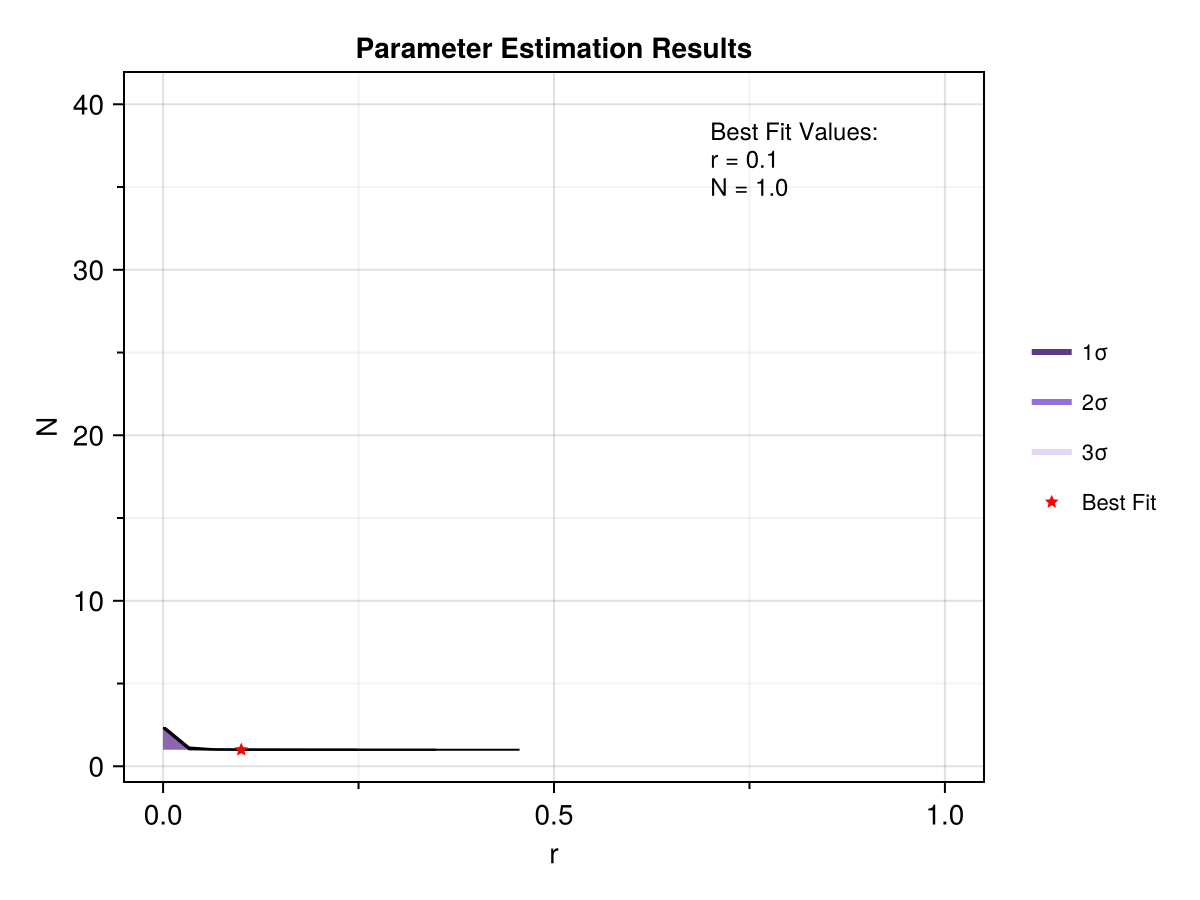

In [13]:
img = CairoMakie.plot(result)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_22/scan_dayabay_Nr_NNM_m0=0.3.png", img)


In [ ]:
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, 15]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, 15]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel = "r",
    ylabel = "Log Posterior",
    title = "r vs Log posterior - Dayabay NNM",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, 25],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_rLogpost_N=50_m0=0.1_NND.png", fig)


Oscillations


In [ ]:

# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

In [ ]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(5), r= ftype(1),))
p_10 = merge(p, (N = ftype(10),r= ftype(1),))
p_20 = merge(p, (N = ftype(20),r= ftype(1),))
p_50 = merge(p, (N = ftype(50),r= ftype(1),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

p_0 = merge(p, (r = ftype(0),))
p_025 = merge(p,  (r = ftype(0.25),))
p_05 = merge(p,  (r = ftype(0.5),))
p_1 = merge(p,  (r = ftype(1),))


probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=true)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=true)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=true)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=true)


In [ ]:
using CairoMakie

In [ ]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Majorana case - r=1"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/plots_22/osc_dayabay_N_NNM_m0=0.1_r=1.png", fig)

fig

In [ ]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Oscillation Probability", 
    title = "Oscillation Probabilities Dayabay - Majorana case - N=100 "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="P(νₑ → νₑ) SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="P(νₑ → νₑ) r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="P(νₑ →  νₑ) r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/new_plots/osc_dayabay_r_NNM_m0=0.1_N=100.png", fig)

fig

In [ ]:
using CairoMakie
f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    

params_temp = merge(p, (N=50, r =1, m₀=0.3))
H, FinalU, h_temp, norm_sector, norm_gamma, gamma, gamma_sq = f1(params_temp)

params_temp_1= merge(p, (N=50, r =1, m₀=0.01))
H_1, FinalU_1, h_temp_1, norm_sector, norm_gamma, gamma, gamma_sq  = f1(params_temp_1)


fig = Figure(size=(1200,500))
ax1 = Axis(fig[1, 1])
hm = heatmap!(ax1, abs.(H), colormap=:viridis)
Colorbar(fig[1, 2], hm, label="Magnitude")
ax2 = Axis(fig[1,3])
hm = heatmap!(ax2, abs.(H_1), colormap=:viridis)
Colorbar(fig[1, 4], hm, label="Magnitude")

ax1.title = " Perturbation m0=0.3 - N=50"
ax2.title = " Perturbation m0.01 - N=50"

fig
    

#save("Mpert_50_NNM.png", fig)

Eigenvalues plotting

In [ ]:


# Plot 1: All eigenvalues vs m1 (scatter plot showing full structure)
function plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="Eigenvalue",
        title="Full Eigenvalue Spectrum vs m₁ - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Plot eigenvalues at each m1 with color coding
    for (i, m1) in enumerate(m1_values)
        eigs = all_eigenvalues[i]  # This is a 1D vector
        if !isempty(eigs)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot each eigenvalue for this m1
            scatter!(ax, fill(m1, length(eigs)), eigs, 
                markersize=8, color=color, alpha=0.7, 
                label="m₁ = $(round(m1, sigdigits=2))")
        end
    end
    
    axislegend(ax, position=:lt, nbanks=2)
    fig
end


# Plot 2: Eigenvalue ratios vs eigenvalue index (colored by m1)
function plot_eigenvalue_ratios(m1_values, all_ratios)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="Eigenvalue Index Ratio (i+1 / i)",
        ylabel="Ratio Value",
        title="Consecutive Eigenvalue Ratios - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Each m1 value gets its own color
    for (i, m1) in enumerate(m1_values)
        ratios = all_ratios[i]
        if !isempty(ratios)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot as line
            lines!(ax, 1:length(ratios), ratios, 
                   label="m₁ = $(round(m1, sigdigits=2))", 
                   linewidth=2.5, color=color)
            # Add markers separately
            scatter!(ax, 1:length(ratios), ratios,
                    markersize=7, color=color)
        end
    end
    
    # Add reference line at y=1 (no hierarchy)
    hlines!(ax, [1.0], color=:black, linestyle=:dash, linewidth=2, label="No structure", alpha=0.5)
    
    axislegend(ax, position=:rt, nbanks=2)
    fig
end


# Plot 3: Perturbation parameter vs m1
function plot_perturbation_parameter(m1_values, all_norm_ratios)
    fig = Figure(size=(1000, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="||M_gamma_factor|| / ||M_sector_part||",
        title="Perturbation Validity - N=10",
        yscale=log10
    )
    
    # Filter out NaN values
    valid_idx = .!isnan.(all_norm_ratios)
    valid_m1 = m1_values[valid_idx]
    valid_ratios = all_norm_ratios[valid_idx]
    
    if !isempty(valid_ratios)
        lines!(ax, valid_m1, valid_ratios, linewidth=3, color=:blue, label="Norm ratio")
        scatter!(ax, valid_m1, valid_ratios, markersize=10, color=:blue)
        
        # Add critical threshold lines
        hlines!(ax, [0.01], color=:green, linestyle=:dash, linewidth=2.5, 
                label="Safe perturbation (< 0.1)", alpha=0.7)
        hlines!(ax, [0.03], color=:orange, linestyle=:dash, linewidth=2.5, 
                label="Marginal (0.1-0.3)", alpha=0.7)
        hlines!(ax, [1.0], color=:red, linestyle=:dash, linewidth=2.5, 
                label="Breakdown (> 1)", alpha=0.7)
    end
    
    axislegend(ax, position=:rt)
    fig
end


# Main analysis function
function analyze_m1_limit(base_params, m1_values)
    """
    Analyze eigenvalue structure vs m1 to find the perturbation limit
    
    Args:
        base_params: NamedTuple with base parameters
        m1_values: Vector of m1 values to scan
        get_Nnaturalness_func: Your function that computes eigenvalues
        N_int: Number of sectors
        r: Sector parameter
    """
    
    all_eigenvalues = []
    all_ratios = []
    all_norm_ratios = []
    
    for m1_test in m1_values
        println("Computing for m1 = $m1_test")
        
        # Update parameters with new m1
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Call your function - it should return eigenvalues
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, norm_sector, norm_gamma = f1(params_test)
            
            # Extract ALL eigenvalues from the full matrix
            # Assuming EIG is a Diagonal matrix or eigenvalues vector
            if isa(EIG, Diagonal)
                eigs_sorted = sort(real.(diag(EIG)))
            else
                eigs_sorted = sort(real.(EIG))
            end
            
            push!(all_eigenvalues, eigs_sorted)
            
            # Compute ratios of consecutive eigenvalues
            if length(eigs_sorted) > 1
                ratios = eigs_sorted[2:end] ./ eigs_sorted[1:end-1]
                push!(all_ratios, ratios)
            else
                push!(all_ratios, [])
            end
            
            # Compute norm ratio (perturbation parameter)
            norm_ratio = norm_gamma / norm_sector
            push!(all_norm_ratios, norm_ratio)
            
            println("  -> $(length(eigs_sorted)) eigenvalues, norm ratio = $(round(norm_ratio, sigdigits=3))")
            
        catch e
            println("  Error: $e")
            push!(all_eigenvalues, [])
            push!(all_ratios, [])
            push!(all_norm_ratios, NaN)
        end
    end
    
    return all_eigenvalues, all_ratios, all_norm_ratios
end



function main(N_int)
    """
    Main function to run the analysis
    
    Usage: main(get_Nnaturalness)
    Pass your get_Nnaturalness function as argument
    """
    N=N_int
    
    # MODIFY THESE WITH YOUR ACTUAL VALUES
    base_params =merge(p, (N=10, r=1))
    
    # Logarithmic scan of m1 values
    m1_values = LinRange(0.0001, 0.0005,10)
    
   
    println("EIGENVALUE STRUCTURE ANALYSIS")
    
    println("Scanning m1 values: $(round.(m1_values, sigdigits=2))\n")
    
    all_eigenvalues, all_ratios, all_norm_ratios = analyze_m1_limit(
        base_params, m1_values
    )
    
    println("GENERATING PLOTS")
    
    
    # Generate Plot 1: Eigenvalues vs m1
    println("Generating Plot 1: Eigenvalues vs m1...")
    fig1 = plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    save("eigenvalues_vs_m1_ex_$N.png", fig1)
    println("✓ Saved: eigenvalues_vs_m1_ex.png\n")
    
    # Generate Plot 2: Eigenvalue ratios
    println("Generating Plot 2: Eigenvalue ratios...")
    fig2 = plot_eigenvalue_ratios(m1_values, all_ratios)
    save("eigenvalue_ratios_vs_m1_ex_$N.png", fig2)
    println("✓ Saved: eigenvalue_ratios_vs_m1.png\n")
    
    # Generate Plot 3: Perturbation parameter
    if !isempty(all_norm_ratios) && !all(isnan.(all_norm_ratios))
        println("Generating Plot 3: Perturbation parameter...")
        fig3 = plot_perturbation_parameter(m1_values, all_norm_ratios)
        save("perturbation_parameter_vs_m1_ex_$N.png", fig3)
        println("✓ Saved: perturbation_parameter_vs_m1.png\n")
    else
        println("⚠ Skipping perturbation plot - no valid norm ratios\n")
    end

    return fig1, fig2, all_eigenvalues, all_ratios, all_norm_ratios
end


# To use this script:
# 1. Make sure your get_Nnaturalness function returns:
#    EIG, FinalUmatrix, h, norm_sector, norm_gamma
# 
fig1, fig2, eigs, ratios, norms = main(10)
#
# Color scheme:
# - Blue: smallest m1 values
# - Red, Green, Orange, etc: progressively larger m1 values
# - Each color appears consistently across all three plots

Gamma plotting

In [ ]:


function plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    """
    Plot gamma and gamma^2 values vs m1
    
    Args:
        m1_values: Vector of m1 values
        all_gamma: Vector of gamma vectors (3 values each)
        all_gamma_squared: Vector of gamma^2 vectors (3 values each)
    """
    
    fig = Figure(size=(1400, 600))
    
    # Plot 1: gamma values
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ value",
        title="γ vs m₁ - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁ = m₁²/m₁²", "γ₂ = m₂²/m₁²", "γ₃ = m₃²/m₁²"]
    
    # Plot each gamma component
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        lines!(ax1, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, gamma_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: gamma^2 values
    ax2 = Axis(fig[1, 2],
        xlabel="m₁ (eV)",
        ylabel="γ² value",
        title="γ² vs m₁  - N=50",
        yscale=log10)
    
    labels_sq = ["γ₁² = m₁⁴/m₁⁴", "γ₂² = m₂⁴/m₁⁴", "γ₃² = m₃⁴/m₁⁴"]
    
    # Plot each gamma^2 component
    for component in 1:3
        gamma_sq_component = [all_gamma_squared[i][component] for i in 1:length(m1_values)]
        lines!(ax2, m1_values, gamma_sq_component, 
               linewidth=2.5, color=colors[component], label=labels_sq[component])
        scatter!(ax2, m1_values, gamma_sq_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax2, position=:rt)
    
    fig
end


function plot_gamma_ratio(m1_values, all_gamma, all_gamma_squared)
    """
    Plot ratio γ²/γ for each component (should equal γ)
    """
    
    fig = Figure(size=(1200, 600))
    
    # Plot 1: Ratio γ²/γ
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ²/γ",
        title="Ratio γ²/γ vs m₁  - N=50",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁²/γ₁", "γ₂²/γ₂", "γ₃²/γ₃"]
    
    # Compute ratios γ²/γ for each component
    for component in 1:3
        ratio_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        lines!(ax1, m1_values, ratio_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, ratio_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: Direct comparison γ vs γ²/γ (verification they're the same)
   #= ax2 = Axis(fig[1, 2],
        xlabel="m₁ (GeV)",
        ylabel="Value",
        title="Verification: γ (line) vs γ²/γ (scatter)",
        xscale=log10,
        yscale=log10)
    
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        ratio_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        
        # Plot γ as line
        lines!(ax2, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], linestyle=:solid, alpha=0.7)
        # Plot γ²/γ as scatter to verify they match
        scatter!(ax2, m1_values, ratio_component, 
                markersize=6, color=colors[component], marker=:circle)
    end
    =#
    fig
end


# Example usage:
function main_gamma(m1_values, base_params)
    """
    Main function to analyze gamma values
    
    Usage: main_gamma(m1_values, get_Nnaturalness, base_params)
    """
    
    all_gamma = []
    all_gamma_squared = []
    
    println("Computing gamma values for different m1...")
    
    for m1_test in m1_values
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Your function should return gamma values
            # Modify this based on what your get_Nnaturalness returns
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, norm_sector, norm_gamma, gamma, gamma_sq = f1(params_test)
          
            
            push!(all_gamma, gamma)
            push!(all_gamma_squared, gamma_sq)
            
            println("m1 = $m1_test: γ = $gamma")
            
        catch e
            println("Error for m1 = $m1_test: $e")
        end
    end
    
    # Generate plots
    fig1 = plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    save("gamma_values_vs_m1_N50_NNM.png", fig1)
    println("\n✓ Saved: gamma_values_vs_m1_N50_NNM.png")

    fig2 = plot_gamma_ratio(m1_values, all_gamma, all_gamma_squared)
    save("gamma_ratios_vs_m1_N50_NNM.png", fig2)
    println("✓ Saved: gamma_ratios_vs_m1_N50_NNM.png")
    
    return fig1, fig2, all_gamma, all_gamma_squared
end
   
# MODIFY THESE WITH YOUR ACTUAL VALUES
base_params =merge(p, (N=50, r=1))

# Logarithmic scan of m1 values
m1_values = LinRange(0.01, 0.05,10)

   
fig1, fig2, all_gamma, all_gamma_squared=main_gamma(m1_values, p)